# Nonlinear Parameter Estimation

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Explain why least-squares fitting is maximum likelihood estimation under Gaussian noise, and estimate the noise level from the residuals
- Compute the Hessian of a loss function with `autograd` and use its inverse to construct confidence intervals for fitted parameters
- Interpret differences in parameter sensitivity and scale (e.g., peak positions vs. peak widths) in terms of the curvature of the loss surface
- Compute and interpret a parameter correlation matrix and a two-parameter confidence ellipse
- Use the Hessian eigenvalue spectrum to diagnose "sloppy" (poorly identified) parameter combinations, and explain why adding model complexity inflates uncertainty
- Cross-check Hessian-based uncertainties against `scipy.optimize.curve_fit`, and explain why the `hess_inv` returned by BFGS should not be trusted for confidence intervals
:::

In [Numerical Optimization](Topic1.4-Numerical_Optimization) we fit a sum of two
Gaussian peaks to a region of the ethanol IR spectrum and declared victory when the
curve passed through the data. But a fitted parameter is a *number computed from noisy
measurements* — repeat the experiment and you would get a slightly different spectrum,
a slightly different fit, and slightly different parameters. Classical **parameter
estimation** asks the follow-up question that every report of a fitted rate constant,
peak position, or activation energy should answer: *how uncertain are the fitted
parameters?*

This chapter develops the classical answer, which connects three ideas that we have
already met separately: least-squares loss functions (Topic 1.3–1.4), derivatives via
automatic differentiation (Topic 1.4), and eigendecomposition (Topic 1.2). The punchline
is that the **curvature of the loss surface at the minimum** — its Hessian matrix —
determines how well the data pin down each parameter.

We begin by reproducing the setup from the previous chapter so this notebook runs on its
own: the C–H stretch region of the ethanol IR spectrum, the multi-Gaussian model, and
the least-squares fit.

fitted parameters: [4.760000e-01 5.650000e-01 2.905485e+03 2.985079e+03 3.881100e+01
 2.539000e+01]


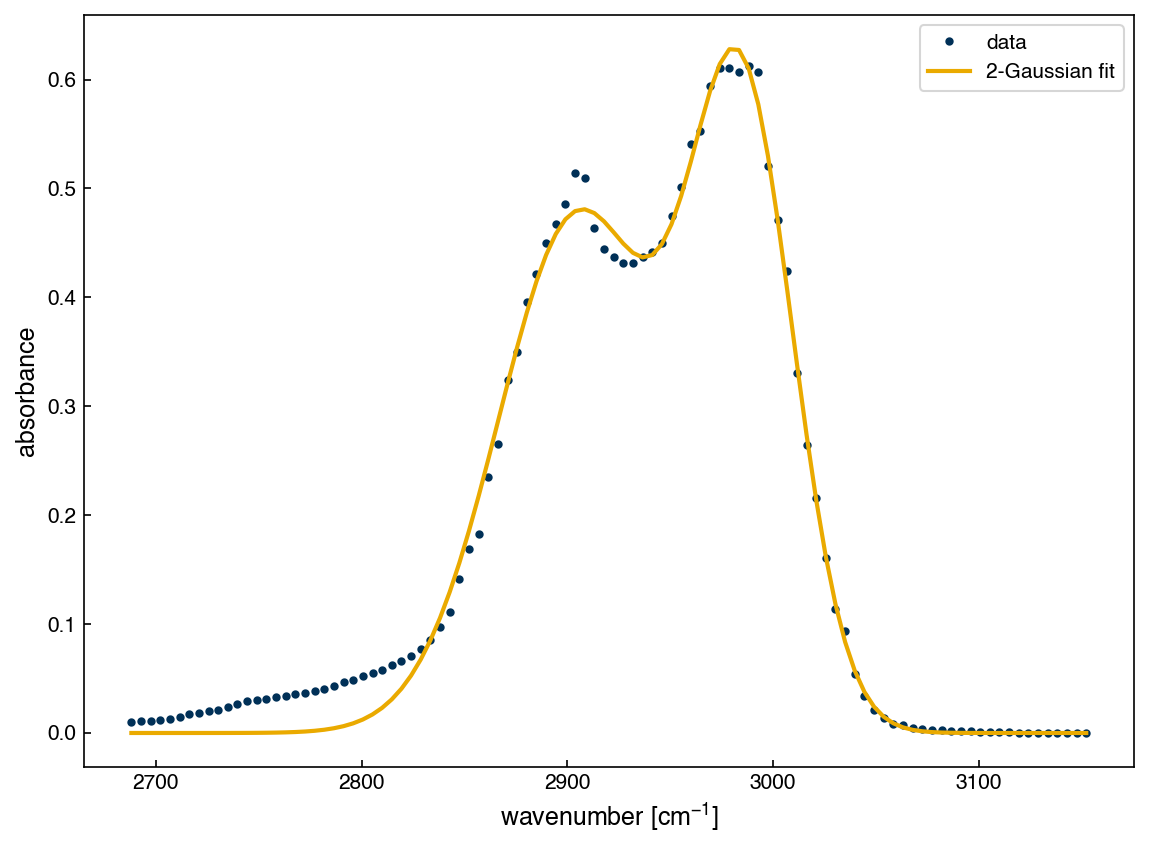

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import autograd.numpy as np   # autograd's numpy, as in the previous chapter
from autograd import hessian
from scipy.optimize import minimize

plt.style.use('../settings/plot_style.mplstyle')
clrs = [p['color'] for p in plt.rcParams['axes.prop_cycle']]

df = pd.read_csv('data/ethanol_IR.csv')
x_all = df['wavenumber [cm^-1]'].values
y_all = df['absorbance'].values
x_peak = x_all[475:575].astype(float)
y_peak = y_all[475:575].astype(float)

def multi_gaussian(lamda, x, m=2):
    """Sum of m Gaussians; lamda = [w_0..w_m, mu_0..mu_m, sigma_0..sigma_m]."""
    yhat = np.zeros(len(x))
    for i in range(m):
        yhat = yhat + lamda[i]*np.exp(-(x - lamda[m+i])**2/(2*lamda[2*m+i]**2))
    return yhat

def sse(lamda, x=x_peak, y=y_peak, m=2):
    """Sum of squared errors (not divided by n)."""
    return np.sum((y - multi_gaussian(lamda, x, m))**2)

guess = np.array([0.545, 0.675, 2900., 2980., 25., 25.])
result = minimize(sse, guess, method='BFGS')
lam_fit = result.x

fig, ax = plt.subplots()
ax.plot(x_peak, y_peak, '.', label='data')
ax.plot(x_peak, multi_gaussian(lam_fit, x_peak), '-', label='2-Gaussian fit')
ax.set_xlabel('wavenumber [cm$^{-1}$]')
ax.set_ylabel('absorbance')
ax.legend()
print('fitted parameters:', np.round(lam_fit, 3))

Note one small bookkeeping change from the previous chapter: `gaussian_loss` there
divided the squared error by the number of points, which is convenient for optimization
but adds a factor of $n$ to every statistical formula below. Here we work directly with
the plain **sum of squared errors (SSE)** — the same minimum, cleaner statistics.

## Least Squares is Maximum Likelihood

Why minimize squared errors in the first place, rather than absolute errors or something
else? The classical justification comes from a noise model. Assume each measurement is
the model prediction plus independent Gaussian noise:

$y_i = f(x_i; \vec{\lambda}) + \epsilon_i, \qquad \epsilon_i \sim \mathcal{N}(0, \sigma^2)$

Under this assumption, the probability density of observing the dataset given the
parameters — the **likelihood** — is a product of Gaussians:

$L(\vec{\lambda}) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - f(x_i; \vec{\lambda}))^2}{2\sigma^2}\right)$

Products of exponentials are awkward, so we take the logarithm and negate it (turning
maximization into the minimization we know how to do). Dropping terms that do not depend
on $\vec{\lambda}$:

$-\ln L(\vec{\lambda}) = \frac{1}{2\sigma^2} \sum_{i=1}^n (y_i - f(x_i; \vec{\lambda}))^2 + \text{const} = \frac{\mathrm{SSE}(\vec{\lambda})}{2\sigma^2} + \text{const}$

The parameters that minimize the SSE are exactly the parameters that maximize the
likelihood: **least squares is maximum likelihood estimation (MLE) for Gaussian noise**.
This is more than a philosophical point — it is what entitles us to the uncertainty
machinery in the rest of this chapter.

The noise level $\sigma$ is usually unknown, but the residuals of the fit estimate it.
With $n$ data points and $p$ fitted parameters,

$\hat{\sigma}^2 = \frac{\mathrm{SSE}(\vec{\lambda}^*)}{n - p}$

(the $n - p$ instead of $n$ accounts for the degrees of freedom "used up" by fitting,
just as in the sample variance):

In [2]:
n, p = len(x_peak), len(lam_fit)
sse_min = sse(lam_fit)
sigma_hat = np.sqrt(sse_min / (n - p))
print(f'SSE at minimum: {sse_min:.4f}')
print(f'Estimated noise level: {sigma_hat:.4f} absorbance units')

SSE at minimum: 0.0347
Estimated noise level: 0.0192 absorbance units


The estimated noise, about 0.02 absorbance units, is our model's claim about the
measurement scatter — everything the data cannot explain with two Gaussians.

:::{exercise}
:label: ex-nm-mle-loglik

Implement the negative log-likelihood directly (including the $\frac{n}{2}\ln(2\pi\sigma^2)$
term) as a function of $\vec{\lambda}$ with $\sigma$ fixed at `sigma_hat`, and minimize it
with `scipy.optimize.minimize` starting from `guess`. Verify that the optimal parameters
agree with the least-squares result `lam_fit`. Why does the value of $\sigma$ not affect
the location of the optimum?
:::

## Curvature Sets Confidence: the Hessian

Two loss surfaces can share the same minimum but differ completely in what they say
about uncertainty. If the loss rises steeply as a parameter moves away from its optimal
value, the data are very informative about that parameter: even a small change makes the
fit visibly worse. If the loss is nearly flat, wide ranges of the parameter fit almost
equally well, and quoting the bottom of the valley alone would be misleading.

We can see both behaviors in our own loss surface by perturbing one parameter at a time
by the same *fractional* amount:

Text(0.5, 1.0, 'The loss is far more sensitive to peak position than width')

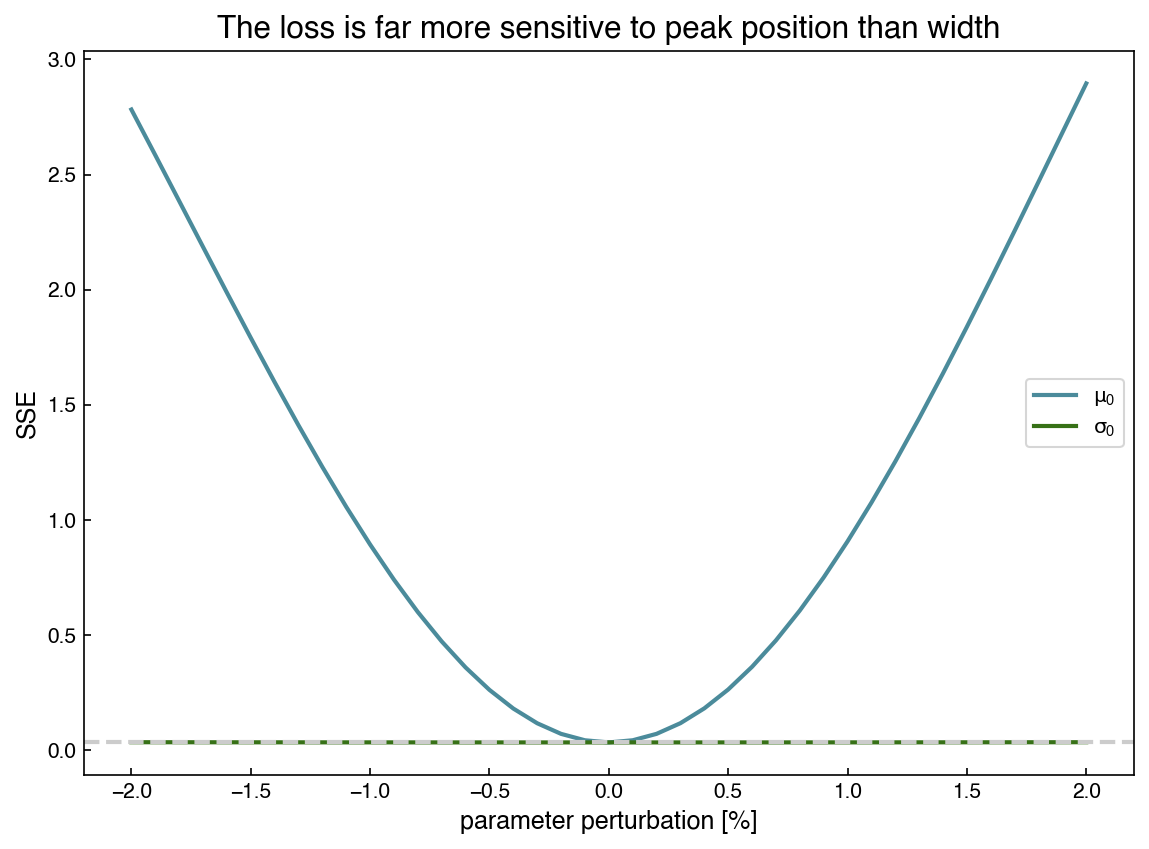

In [3]:
labels = ['$w_0$', '$w_1$', '$\\mu_0$', '$\\mu_1$', '$\\sigma_0$', '$\\sigma_1$']
fracs = np.linspace(-0.02, 0.02, 41)   # +/- 2% perturbations

fig, ax = plt.subplots()
for j in [2, 4]:   # mu_0 vs sigma_0
    losses = []
    for f in fracs:
        lam_pert = lam_fit.copy()
        lam_pert[j] = lam_fit[j]*(1 + f)
        losses.append(sse(lam_pert))
    ax.plot(fracs*100, losses, label=labels[j], color=clrs[j % len(clrs)])
ax.axhline(sse_min, color='0.8', linestyle='--')
ax.set_xlabel('parameter perturbation [%]')
ax.set_ylabel('SSE')
ax.legend()
ax.set_title('The loss is far more sensitive to peak position than width')

A 2% error in the peak position $\mu_0$ is catastrophic for the fit, while a 2% error in
the width $\sigma_0$ barely registers — the data "grip" the two parameters with very
different strength. This is a general feature of spectral fitting: positions are sharply
determined, shapes much less so.

The **Hessian matrix** $H_{jk} = \partial^2 \mathrm{SSE} / \partial\lambda_j \partial\lambda_k$
evaluated at the minimum captures all of these curvatures (and their interactions) at
once. Writing it out by hand for six parameters would be painful, but `autograd`, which
gave us gradients in the previous chapter, provides Hessians just as easily:

In [4]:
H = hessian(sse)(lam_fit)
print('Hessian shape:', H.shape)

Hessian shape: (6, 6)


The classical result — derived by expanding the log-likelihood to second order around
its maximum, and closely related to the *Fisher information* — is that the parameter
**covariance matrix** is proportional to the inverse Hessian:

$\mathrm{Cov}(\vec{\lambda}^*) \approx 2\hat{\sigma}^2 H^{-1}$

(The factor of 2 comes from $-\ln L = \mathrm{SSE}/2\sigma^2$: the curvature of the
log-likelihood is $H/2\hat{\sigma}^2$, and the covariance is its inverse.) The square
roots of the diagonal are the **standard errors** of each parameter, and multiplying by
1.96 gives (approximate) 95% confidence intervals:

In [5]:
cov = 2 * sigma_hat**2 * np.linalg.inv(H)
se = np.sqrt(np.diag(cov))

names = ['w0', 'w1', 'mu0', 'mu1', 'sigma0', 'sigma1']
print(f'{"param":8s}{"value":>12s}{"std err":>10s}{"95% CI":>22s}{"rel. err":>10s}')
for nm, v, s in zip(names, lam_fit, se):
    print(f'{nm:8s}{v:12.3f}{s:10.3f}   [{v - 1.96*s:9.3f}, {v + 1.96*s:9.3f}]'
          f'{100*s/abs(v):9.2f}%')

param          value   std err                95% CI  rel. err
w0             0.476     0.007   [    0.463,     0.490]     1.42%
w1             0.565     0.015   [    0.536,     0.594]     2.64%
mu0         2905.485     1.573   [ 2902.403,  2908.567]     0.05%
mu1         2985.079     0.884   [ 2983.347,  2986.811]     0.03%
sigma0        38.811     1.499   [   35.873,    41.748]     3.86%
sigma1        25.390     0.663   [   24.091,    26.688]     2.61%


:::{note}
For small datasets the 1.96 multiplier (from the normal distribution) should be replaced
by the corresponding value of Student's t-distribution with $n - p$ degrees of freedom.
With $n - p = 94$ here the difference is negligible ($t \approx 1.99$); Himmelblau's
*Process Analysis by Statistical Methods* treats the small-sample case carefully.
:::

Look at the relative errors, because the parameters live on wildly different scales
(absorbances near 0.5, wavenumbers near 2900, widths near 30): the peak *positions* are
determined to about 0.03–0.05% — 95% confidence intervals spanning only a few
wavenumbers out of ~2900 — while the *weights* and *widths* are only known to a few
percent. The confidence intervals turn the curvature
picture above into concrete error bars, and they inherit its message: the same dataset
determines different parameters with very different precision.

:::{note}
**Penalties change what the error bars mean.** A penalty term added to the loss — like
the soft width constraint in the previous chapter — is extra information supplied by
*you*, not by the data. It steepens the loss surface, so the Hessian-based error bars
get smaller; but the intervals now describe uncertainty given the data *plus your
assumption*, and the fitted parameters are pulled away from the values the data alone
prefer. If the assumption is wrong, the result is an interval that is tighter but
centered in the wrong place. The exercise below makes this concrete.
:::

:::{exercise}
:label: ex-nm-hess-ci

The previous chapter's `g_simwidth` loss added a soft constraint pulling the two peak
widths together. Here, use a *quadratic* version of that idea: minimize
$\mathrm{SSE}(\vec{\lambda}) + \alpha(\sigma_0 - \sigma_1)^2$ for
$\alpha \in \{0.001, 0.01, 1\}$.

1. For each $\alpha$, compute Hessian-based standard errors for the two widths and the
   correlation between them. How do the error bars and $\mathrm{corr}(\sigma_0, \sigma_1)$
   change as $\alpha$ grows?
2. The error bars *shrink* — but the extra certainty did not come from the spectrum.
   Compare the fitted widths to the unconstrained values and explain, in plain terms,
   what the tighter intervals represent and when they could be misleading.
3. Repeat part 1 using the previous chapter's absolute-value penalty
   $|\sigma_0 - \sigma_1|$ instead. What goes wrong with the Hessian calculation, and
   why? (Think about the second derivative of $|x|$ near $x = 0$.)
:::

## Parameter Correlations

The off-diagonal entries of the covariance matrix say how estimation errors in different
parameters move *together*, and are easiest to read after normalizing to a
**correlation matrix**:

Text(0.5, 1.0, 'Parameter correlation matrix (2-Gaussian fit)')

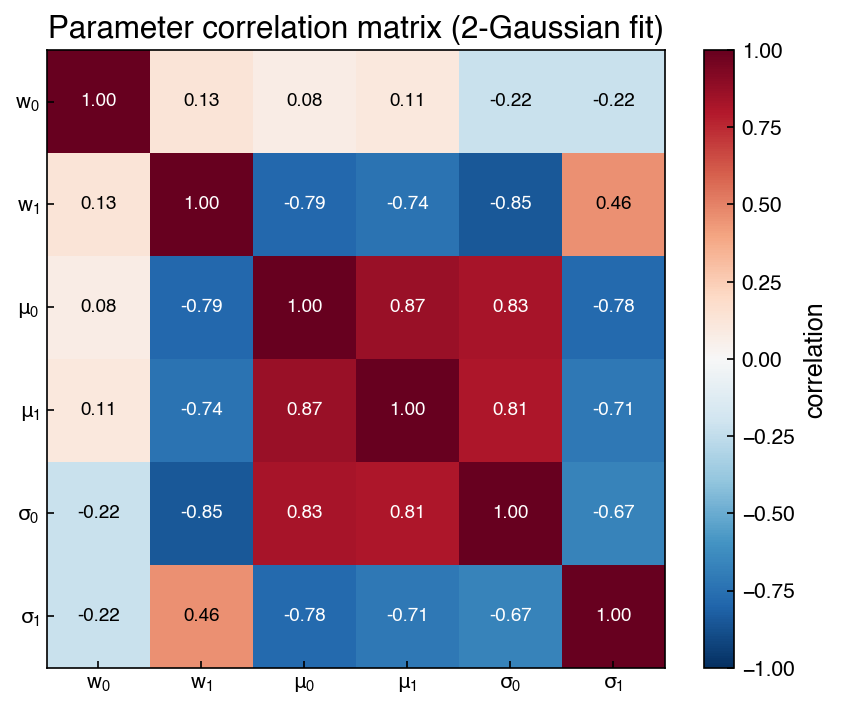

In [6]:
corr = cov / np.outer(se, se)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(p)); ax.set_xticklabels(labels)
ax.set_yticks(range(p)); ax.set_yticklabels(labels)
for i in range(p):
    for j in range(p):
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(corr[i, j]) > 0.6 else 'black')
fig.colorbar(im, ax=ax, label='correlation')
ax.set_title('Parameter correlation matrix (2-Gaussian fit)')

The structure is striking: the strongest correlations are not within a single peak but
**between the two peaks**. The two centers move together
($\mathrm{corr}(\mu_0, \mu_1) \approx +0.87$), and the second peak's weight trades off
against the first peak's width ($\mathrm{corr}(w_1, \sigma_0) \approx -0.85$). The
physical reason is that the peaks overlap: absorbance in the shoulder region between
them can be explained by either peak, so the fit can shift intensity from one to the
other with little penalty. Overlapping features entangle each other's parameters — a
fact worth remembering whenever a deconvolution is reported.

A two-parameter slice of the covariance can be drawn as a **confidence ellipse**. Its
principal axes are the eigenvectors of the corresponding $2\times 2$ covariance block —
the eigendecomposition machinery from [Linear Algebra](Topic1.2-Linear_Algebra) — and
strong correlation shows up as a long, tilted ellipse:

Text(0.5, 1.0, '68% and 95% confidence ellipses for $(w_1, \\sigma_0)$')

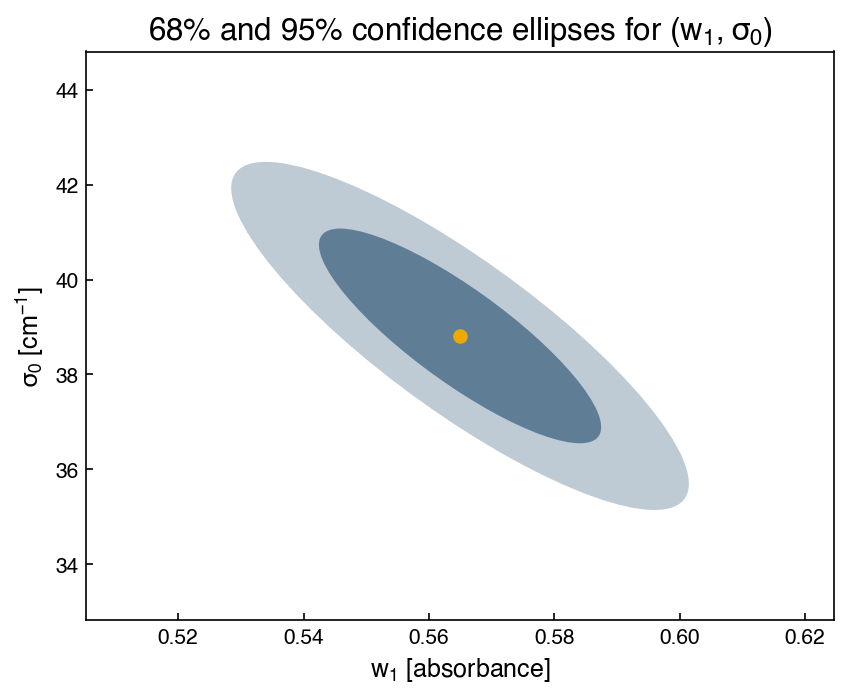

In [7]:
from matplotlib.patches import Ellipse
from scipy.stats import chi2

idx = [1, 4]   # (w_1, sigma_0): the strongly anti-correlated pair
sub = cov[np.ix_(idx, idx)]
evals, evecs = np.linalg.eigh(sub)
angle = np.degrees(np.arctan2(evecs[1, -1], evecs[0, -1]))

fig, ax = plt.subplots(figsize=(6, 5))
for conf, alpha in [(0.68, 0.5), (0.95, 0.25)]:
    r = np.sqrt(chi2.ppf(conf, df=2))
    ax.add_patch(Ellipse((lam_fit[idx[0]], lam_fit[idx[1]]),
                         width=2*r*np.sqrt(evals[-1]), height=2*r*np.sqrt(evals[0]),
                         angle=angle, facecolor=clrs[0], alpha=alpha, edgecolor='none'))
ax.plot(lam_fit[idx[0]], lam_fit[idx[1]], 'o', color=clrs[1])
ax.set_xlim(lam_fit[idx[0]] - 4*se[idx[0]], lam_fit[idx[0]] + 4*se[idx[0]])
ax.set_ylim(lam_fit[idx[1]] - 4*se[idx[1]], lam_fit[idx[1]] + 4*se[idx[1]])
ax.set_xlabel('$w_1$ [absorbance]')
ax.set_ylabel('$\\sigma_0$ [cm$^{-1}$]')
ax.set_title('68% and 95% confidence ellipses for $(w_1, \\sigma_0)$')

The tilt encodes the correlation: if new data pushed $w_1$ up, our best estimate of
$\sigma_0$ would move down in a predictable way. Quoting the two 1-D confidence
intervals alone would miss this — the ellipse contains combinations of parameters that
the intervals individually allow but the data jointly rule out.

The same eigendecomposition applied to the full $6\times 6$ Hessian reveals the global
structure of the problem: each eigenvector is a *combination* of parameters, and its
eigenvalue is the curvature of the loss along that combination. In fitting problems
these eigenvalues typically span many orders of magnitude — a few **stiff** directions
the data determine sharply, and softer, **sloppy** directions the data barely see:

In [8]:
eigvals = np.linalg.eigvalsh(H)
print('Hessian eigenvalues:', [f'{v:.2e}' for v in eigvals])
print(f'Condition number: {eigvals[-1]/eigvals[0]:.1e}')

Hessian eigenvalues: ['1.42e-04', '1.73e-03', '4.71e-03', '4.98e-03', '1.70e+01', '3.16e+01']
Condition number: 2.2e+05


Five orders of magnitude separate the stiffest direction from the sloppiest — and this
is with a model that fits *well*. (Part of the spread simply reflects units: wavenumbers
and absorbances have very different magnitudes, which is why the unit-free relative
errors and correlations above are often more interpretable than raw eigenvalues.)

:::{exercise}
:label: ex-nm-corr-pairs

From the correlation matrix, identify (a) the most strongly correlated parameter pair
and (b) the pair closest to uncorrelated. For each, give a one-sentence physical
explanation in terms of the two overlapping peaks. Then re-draw the confidence ellipse
for the pair from (b) and describe how its shape differs.
:::

## Sloppiness Grows with Model Complexity

What happens if we add a third Gaussian? The fit can only improve — more parameters
never increase the minimum SSE — but parameter estimation tells a different story than
the loss value alone:

3-Gaussian parameters: [ 6.10000e-01  3.40000e-01 -1.90000e-01  2.92715e+03  2.99171e+03
  2.93149e+03  4.83100e+01  1.98700e+01  1.70300e+01]
SSE: 0.0347 (m=2)  ->  0.0266 (m=3)


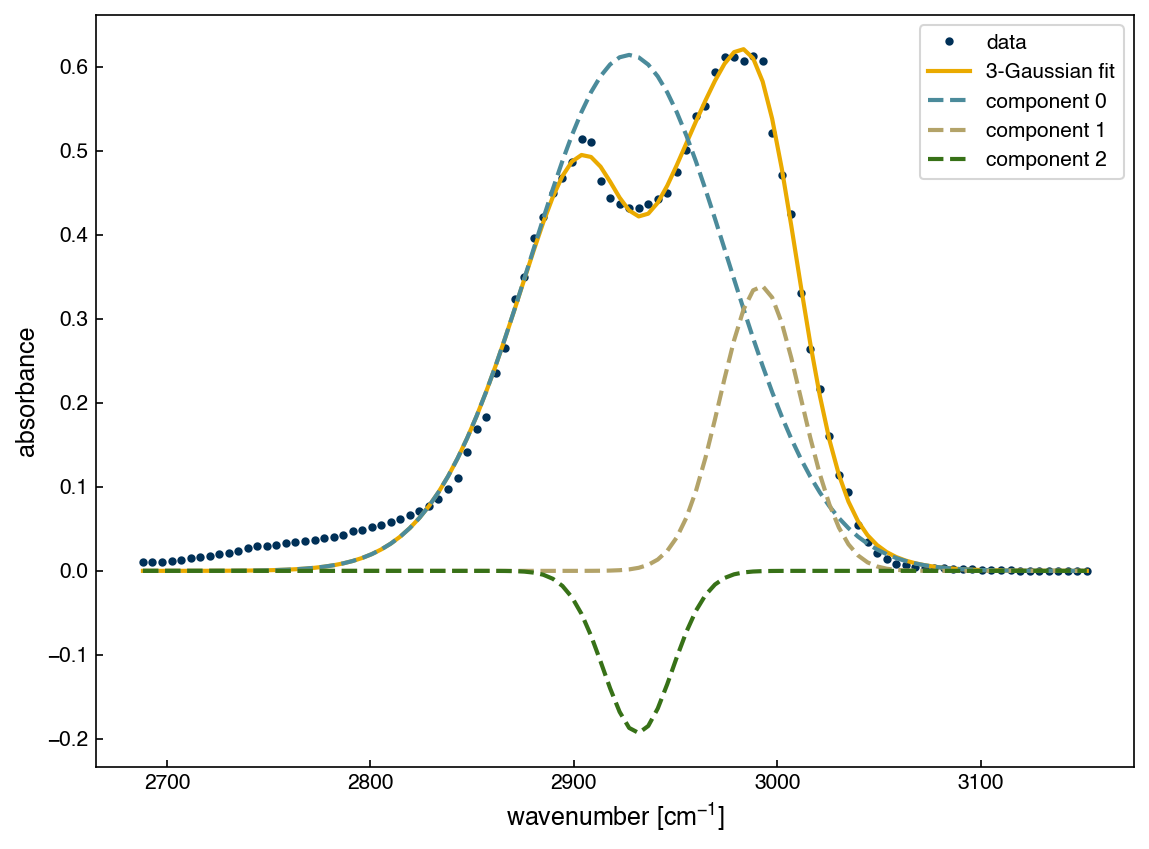

In [9]:
guess3 = np.array([0.5, 0.6, 0.2, 2900., 2980., 2940., 25., 25., 15.])
def sse3(lamda):
    return sse(lamda, m=3)

result3 = minimize(sse3, guess3, method='BFGS')
lam3 = result3.x
print('3-Gaussian parameters:', np.round(lam3, 2))
print(f'SSE: {sse(lam_fit):.4f} (m=2)  ->  {sse3(lam3):.4f} (m=3)')

fig, ax = plt.subplots()
ax.plot(x_peak, y_peak, '.', label='data')
ax.plot(x_peak, multi_gaussian(lam3, x_peak, m=3), '-', label='3-Gaussian fit')
for i in range(3):
    comp = lam3[i]*np.exp(-(x_peak - lam3[3+i])**2/(2*lam3[6+i]**2))
    ax.plot(x_peak, comp, '--', label=f'component {i}')
ax.set_xlabel('wavenumber [cm$^{-1}$]')
ax.set_ylabel('absorbance')
ax.legend()

The SSE drops by about 17% — but look at the components: the third Gaussian has fit a
**negative** weight, carving a dip out of the other two peaks rather than describing any
physical absorption. The optimizer is using the extra flexibility to chase noise and
baseline structure, not chemistry.

The Hessian makes the diagnosis quantitative:

smallest m=3 eigenvalues: ['4.7e-05', '1.9e-04', '3.4e-04']


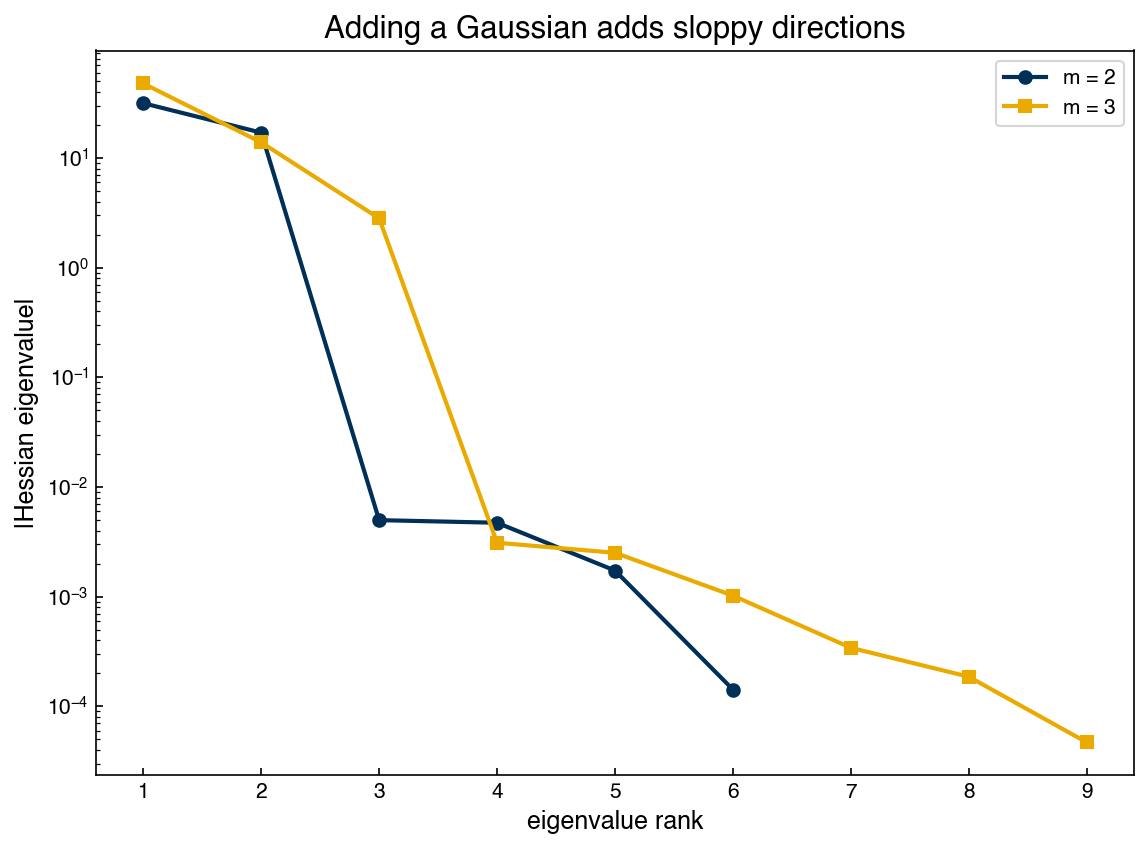

In [10]:
H3 = hessian(sse3)(lam3)
eig3 = np.linalg.eigvalsh(H3)

fig, ax = plt.subplots()
ax.semilogy(range(1, 7), np.abs(np.linalg.eigvalsh(H))[::-1], 'o-', label='m = 2')
ax.semilogy(range(1, 10), np.abs(eig3)[::-1], 's-', label='m = 3')
ax.set_xlabel('eigenvalue rank')
ax.set_ylabel('|Hessian eigenvalue|')
ax.legend()
ax.set_title('Adding a Gaussian adds sloppy directions')

print('smallest m=3 eigenvalues:', [f'{v:.1e}' for v in eig3[:3]])

The three-Gaussian Hessian's smallest eigenvalue is not just small — it is *slightly
negative* (about $-2\times 10^{-5}$, i.e. zero to within numerical precision). Along
that direction the loss surface is flat: the data contain essentially no information
about that combination of parameters, so the optimizer stopped somewhere on a plateau
rather than in a true bowl. The covariance formula $2\hat{\sigma}^2 H^{-1}$ breaks down
entirely for such directions (a non-positive-definite Hessian implies infinite or
undefined variances), which is the mathematics telling us the model is
**unidentifiable**: the data cannot support nine parameters.

Even the parameters we could estimate before have suffered. Repeating the standard-error
calculation for the parameters shared with the two-Gaussian model shows the first peak's
weight uncertainty growing about six-fold and the position uncertainties roughly
doubling — the extra peak's flexibility "steals" information from every other parameter.
This is the parameter-estimation view of **overfitting**, and we will meet the same
phenomenon through the lens of model complexity and validation in Module 2.

:::{exercise}
:label: ex-nm-sloppy-m

Fit the peak window with $m = 1, 2, 3,$ and $4$ Gaussians (choose reasonable initial
guesses). For each fit, record the SSE, the smallest and largest Hessian eigenvalue
magnitudes, and the condition number $|\lambda_\max / \lambda_\min|$. Present the
results as a table. At what $m$ does the problem become effectively unidentifiable, and
how does the SSE improvement compare to the loss of identifiability?
:::

## Cross-checks and Practical Tools

The machinery above is standard enough that scipy packages it:
`scipy.optimize.curve_fit` performs the nonlinear least-squares fit *and* returns a
parameter covariance matrix `pcov` in one call. It is a good independent check on our
autograd-based calculation:

In [11]:
from scipy.optimize import curve_fit

def model_2g(x, *lamda):
    return multi_gaussian(np.array(lamda), x, m=2)

popt, pcov = curve_fit(model_2g, x_peak, y_peak, p0=guess)
print(f'{"param":8s}{"curve_fit se":>14s}{"autograd se":>14s}')
for nm, s_cf, s_ag in zip(names, np.sqrt(np.diag(pcov)), se):
    print(f'{nm:8s}{s_cf:14.4f}{s_ag:14.4f}')

param     curve_fit se   autograd se
w0              0.0067        0.0067
w1              0.0134        0.0149
mu0             1.4931        1.5725
mu1             0.8270        0.8837
sigma0          1.2682        1.4988
sigma1          0.6535        0.6626


The two agree to within a few percent. They are not identical because `curve_fit`
estimates the curvature from the model's Jacobian (the *Gauss–Newton* approximation,
which drops a term involving the residuals), while `autograd` computes the exact
Hessian; near a good fit with small residuals the difference is minor.

:::{warning}
`scipy.optimize.minimize(..., method='BFGS')` returns an attribute called `hess_inv`
that looks temptingly like exactly what we need. **Do not use it for confidence
intervals.** BFGS builds up its inverse-Hessian estimate iteratively as a by-product of
the search, and the result depends on the starting point and path taken — it is a search
tool, not a converged curvature calculation. In this problem it happens to land within
~10% of the true values; in general there is no such guarantee. Compute the Hessian
properly (automatic differentiation, `curve_fit`'s Jacobian-based `pcov`, or finite
differences at the optimum).
:::

Finally, the classical intervals rest on assumptions worth restating: Gaussian,
independent noise with constant variance; a model flexible enough that the remaining
residuals are actually noise; and enough data that the quadratic (second-order)
expansion of the likelihood is accurate. When these fail — strongly non-Gaussian errors,
parameters at physical bounds, or the unidentifiable regime we just saw — the honest
alternatives are computational: the **bootstrap** (refitting on resampled data), which
we develop in Module 2's [Model Validation](../2-regression/Topic2.2-Model_Validation)
chapter, makes far weaker assumptions at the cost of many repeated fits.

:::{exercise}
:label: ex-nm-pcov-check

Use `curve_fit` to fit the three-Gaussian model from the previous section (pass
`p0=guess3` and `maxfev=10000` if needed). Compare the standard errors from `pcov` to
the two-Gaussian values, and check whether `curve_fit` warns about the covariance
estimate. Do the two approaches (exact Hessian vs. Jacobian-based) agree about which
parameters are poorly determined?
:::

## Summary

- Least-squares fitting is **maximum likelihood estimation** under independent Gaussian
  noise; the residuals estimate the noise level via $\hat{\sigma}^2 = \mathrm{SSE}/(n-p)$.
- The **Hessian of the loss at the minimum** measures how sharply the data determine
  each parameter; `autograd`'s `hessian` computes it in one line.
- The parameter covariance is $\mathrm{Cov} \approx 2\hat{\sigma}^2 H^{-1}$; square roots
  of its diagonal give standard errors and confidence intervals. Relative errors are the
  fair comparison when parameters live on different scales — for the ethanol spectrum,
  peak positions are known to ~0.05% but widths only to a few percent.
- Off-diagonal covariance entries reveal **parameter correlations**; overlapping peaks
  entangle each other's parameters, and confidence ellipses (eigenvectors of the
  covariance) show the joint uncertainty that 1-D intervals miss.
- Hessian **eigenvalue spectra** expose stiff and sloppy parameter combinations. Adding
  model complexity beyond what the data support drives eigenvalues to zero (an
  unidentifiable model), produces unphysical compensating parameters, and inflates the
  uncertainty of *every* parameter — overfitting, seen through curvature.
- Cross-check with `curve_fit`'s `pcov`; never use BFGS's iterative `hess_inv` for
  confidence intervals.

## Additional Reading

- Himmelblau, D. M., *Process Analysis by Statistical Methods* (Wiley, 1970) — the
  classical chemical engineering treatment of parameter estimation and experimental
  statistics
- Bard, Y., *Nonlinear Parameter Estimation* (Academic Press, 1974) — the standard
  reference for the theory of nonlinear estimation, including likelihood methods and
  confidence regions
- Seber, G. A. F. and Wild, C. J., *Nonlinear Regression* (Wiley, 2003) — a modern and
  comprehensive treatment
- Transtrum, M. K., Machta, B. B., and Sethna, J. P. (2011),
  ["Geometry of nonlinear least squares with applications to sloppy models and optimization"](https://doi.org/10.1103/PhysRevE.83.036701),
  *Phys. Rev. E* 83, 036701 — where the "sloppy model" perspective comes from
- [scipy.optimize.curve_fit documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)